In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/nsynth-test"
AUDIO_PATH = DATASET_ROOT + "/audio"
JSON_PATH = DATASET_ROOT + "/examples.json"


In [ ]:
import os
import json
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random


In [ ]:
!tar -xvzf /content/drive/MyDrive/nsynth-test.jsonwav.tar.gz -C /content/drive/MyDrive


nsynth-test/
nsynth-test/audio/
nsynth-test/audio/guitar_acoustic_010-097-025.wav
nsynth-test/audio/reed_acoustic_023-050-025.wav
nsynth-test/audio/guitar_acoustic_010-049-100.wav
nsynth-test/audio/bass_synthetic_034-039-050.wav
nsynth-test/audio/brass_acoustic_015-052-075.wav
nsynth-test/audio/bass_synthetic_134-065-127.wav
nsynth-test/audio/keyboard_electronic_003-065-127.wav
nsynth-test/audio/organ_electronic_007-020-100.wav
nsynth-test/audio/flute_synthetic_000-022-050.wav
nsynth-test/audio/guitar_acoustic_030-043-075.wav
nsynth-test/audio/keyboard_acoustic_004-105-025.wav
nsynth-test/audio/guitar_electronic_028-030-050.wav
nsynth-test/audio/keyboard_electronic_002-021-127.wav
nsynth-test/audio/organ_electronic_028-062-075.wav
nsynth-test/audio/string_acoustic_014-064-075.wav
nsynth-test/audio/guitar_acoustic_014-099-025.wav
nsynth-test/audio/string_acoustic_056-060-075.wav
nsynth-test/audio/keyboard_acoustic_004-082-100.wav
nsynth-test/audio/keyboard_electronic_078-030-127.wav
nsy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/nsynth-test


audio  examples.json


In [ ]:
import json

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Total audio samples:", len(metadata))


Total audio samples: 4096


In [ ]:
instrument_files = {}

for key, value in metadata.items():
    instrument = value["instrument_family_str"]
    filename = key + ".wav"

    if instrument not in instrument_files:
        instrument_files[instrument] = []

    instrument_files[instrument].append(filename)

# Print available instrument classes
for inst in instrument_files:
    print(inst, ":", len(instrument_files[inst]))


bass : 843
keyboard : 766
guitar : 652
reed : 235
flute : 180
string : 306
vocal : 141
brass : 269
mallet : 202
organ : 502


In [ ]:
SAMPLE_RATE = 22050
DURATION = 4  # seconds
SAMPLES = SAMPLE_RATE * DURATION

# pick a random instrument & file
instrument = random.choice(list(instrument_files.keys()))
file_name = random.choice(instrument_files[instrument])
file_path = os.path.join(AUDIO_PATH, file_name)

y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

# Fix duration (trim or pad)
if len(y) > SAMPLES:
    y = y[:SAMPLES]
else:
    y = np.pad(y, (0, SAMPLES - len(y)))

print("Instrument:", instrument)
print("Audio shape:", y.shape)


Instrument: brass
Audio shape: (88200,)


In [ ]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=8000
)

mel_db = librosa.power_to_db(mel_spec, ref=np.max)


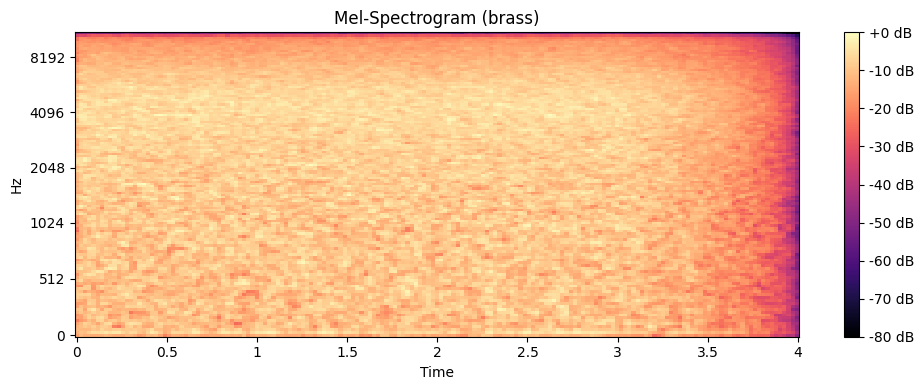

In [ ]:
plt.figure(figsize=(10,4))
librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel-Spectrogram ({instrument})")
plt.tight_layout()
plt.show()


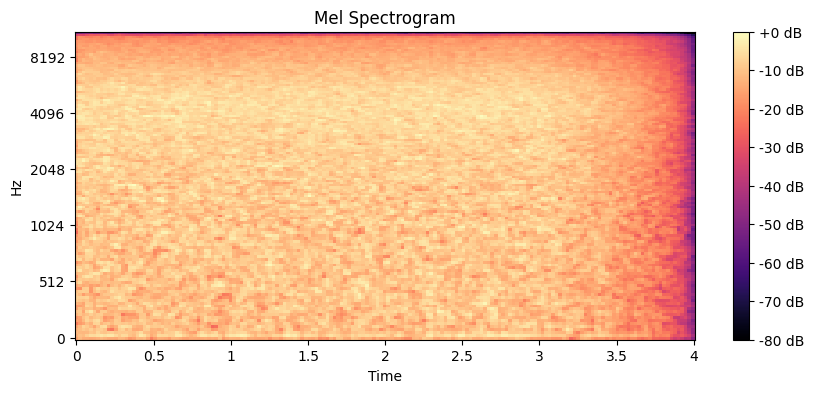

In [ ]:
plt.figure(figsize=(10,4))
librosa.display.specshow(mel_db, sr=22050, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()


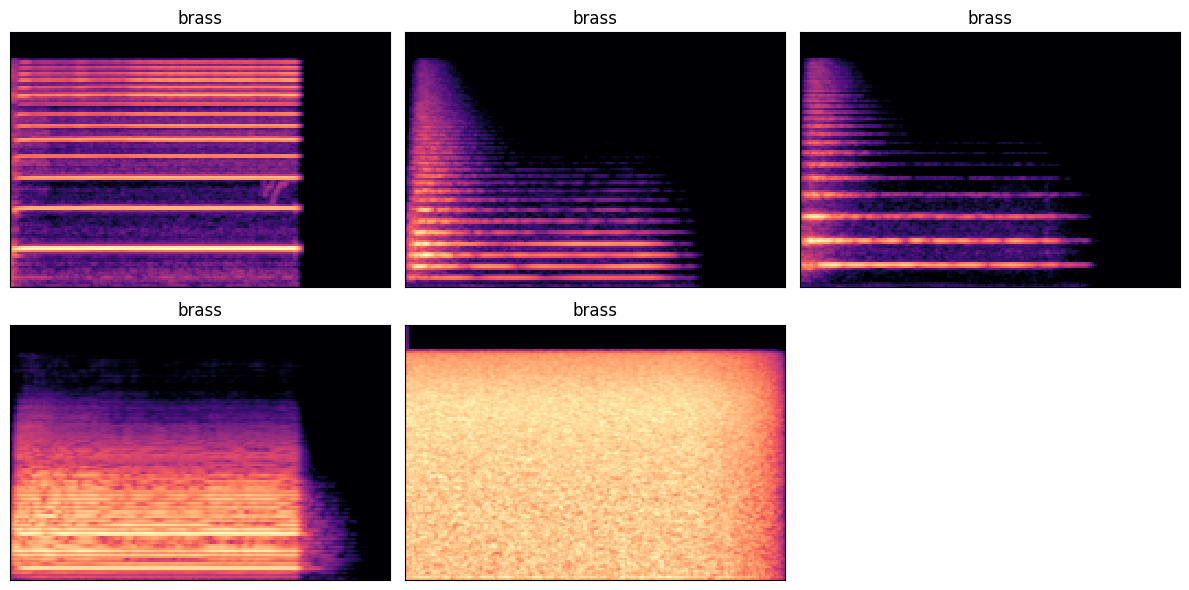

In [ ]:
plt.figure(figsize=(12,6))

for i in range(5):
    file_name = random.choice(instrument_files[instrument])
    file_path = os.path.join(AUDIO_PATH, file_name)

    y, _ = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    y = librosa.util.fix_length(y, size=SAMPLES)

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.subplot(2,3,i+1)
    librosa.display.specshow(mel_db, sr=sr, x_axis=None, y_axis=None)
    plt.title(instrument)

plt.tight_layout()
plt.show()


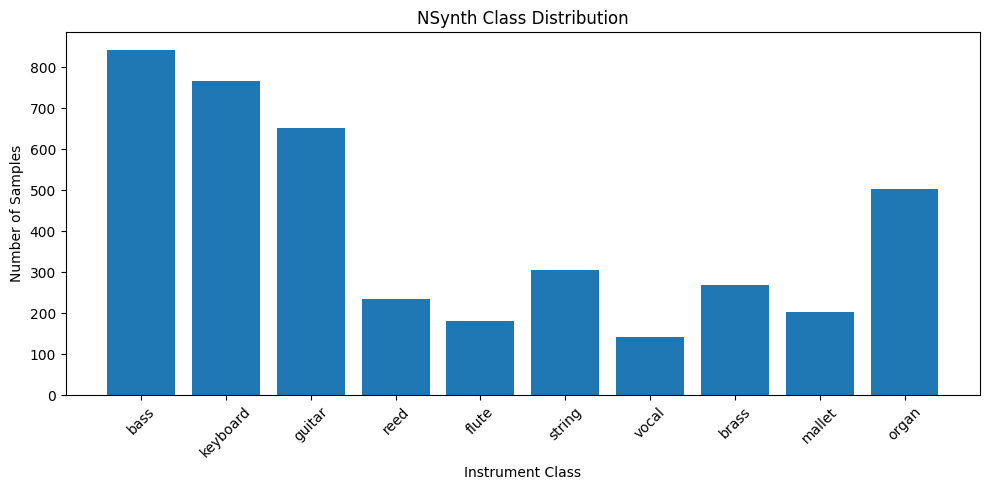

In [ ]:
classes = list(instrument_files.keys())
counts = [len(instrument_files[c]) for c in classes]

plt.figure(figsize=(10,5))
plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.xlabel("Instrument Class")
plt.ylabel("Number of Samples")
plt.title("NSynth Class Distribution")
plt.tight_layout()
plt.show()

In [ ]:
instrument_family_files = {}

for key, value in metadata.items():
    family = value["instrument_family_str"]
    filename = key + ".wav"

    if family not in instrument_family_files:
        instrument_family_files[family] = []

    instrument_family_files[family].append(filename)


In [ ]:
SAMPLE_RATE = 22050
DURATION = 4
SAMPLES = SAMPLE_RATE * DURATION
MAX_FILES_PER_CLASS = 20  # keep small for speed

boxplot_data = {}

for family, files in instrument_family_files.items():
    intensities = []

    selected_files = random.sample(files, min(len(files), MAX_FILES_PER_CLASS))

    for file_name in selected_files:
        file_path = os.path.join(AUDIO_PATH, file_name)

        try:
            y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
            y = librosa.util.fix_length(y, size=SAMPLES)

            mel = librosa.feature.melspectrogram(y=y, sr=sr)
            mel_db = librosa.power_to_db(mel, ref=np.max)

            intensities.extend(mel_db.flatten())

        except Exception as e:
            continue

    if len(intensities) > 0:
        boxplot_data[family] = intensities


/tmp/ipython-input-3367941363.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


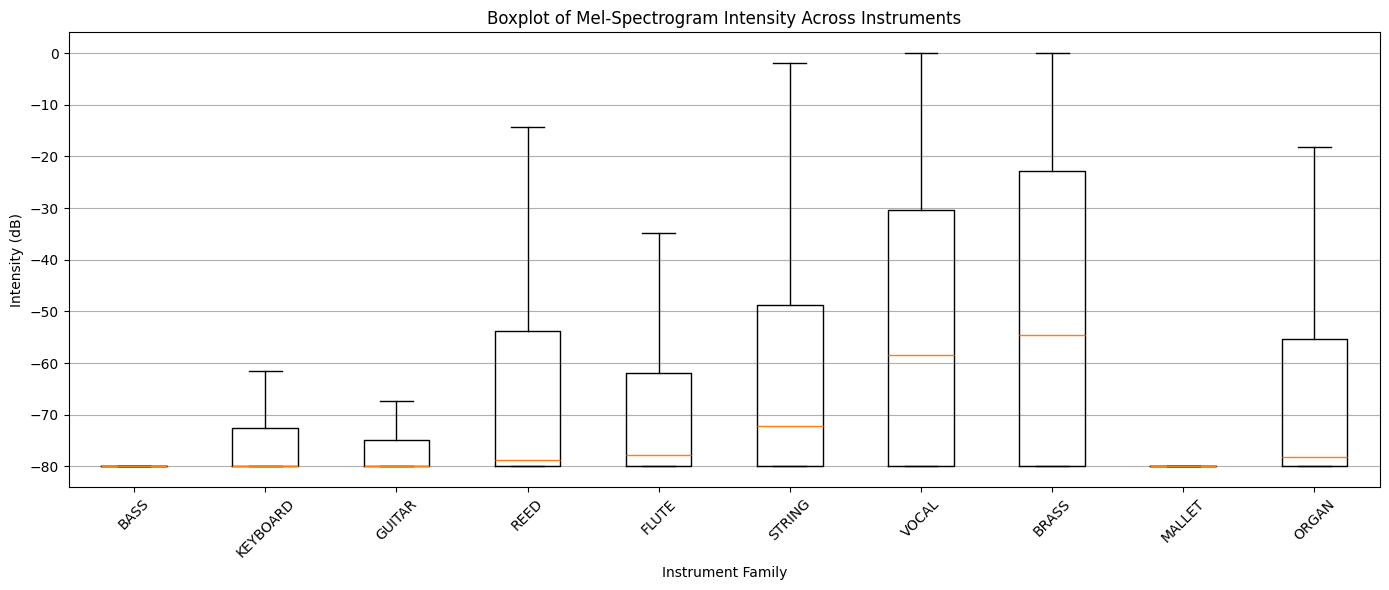

In [ ]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    boxplot_data.values(),
    labels=[k.upper() for k in boxplot_data.keys()],
    showfliers=False
)

plt.title("Boxplot of Mel-Spectrogram Intensity Across Instruments")
plt.ylabel("Intensity (dB)")
plt.xlabel("Instrument Family")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()


In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/processed_spectrograms"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.listdir(OUTPUT_DIR)


['bass',
 'keyboard',
 'guitar',
 'reed',
 'flute',
 'string',
 'vocal',
 'brass',
 'mallet',
 'organ']

In [ ]:
for family in instrument_family_files.keys():
    os.makedirs(os.path.join(OUTPUT_DIR, family), exist_ok=True)


In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random

SAMPLE_RATE = 22050
DURATION = 4
SAMPLES = SAMPLE_RATE * DURATION
MAX_FILES_PER_CLASS = 5  # small number for demo

for family, files in instrument_family_files.items():
    selected_files = random.sample(files, min(len(files), MAX_FILES_PER_CLASS))

    for idx, file_name in enumerate(selected_files):
        file_path = os.path.join(AUDIO_PATH, file_name)

        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
        y = librosa.util.fix_length(y, size=SAMPLES)
        mel_db = librosa.power_to_db(mel, ref=1.0)
        mel_db = np.nan_to_num(mel_db)

        plt.figure(figsize=(3,3))
        librosa.display.specshow(mel_db, sr=sr)
        plt.axis("off")

        save_path = os.path.join(
            OUTPUT_DIR, family, f"{family}_{idx}.png"
        )
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        plt.close()


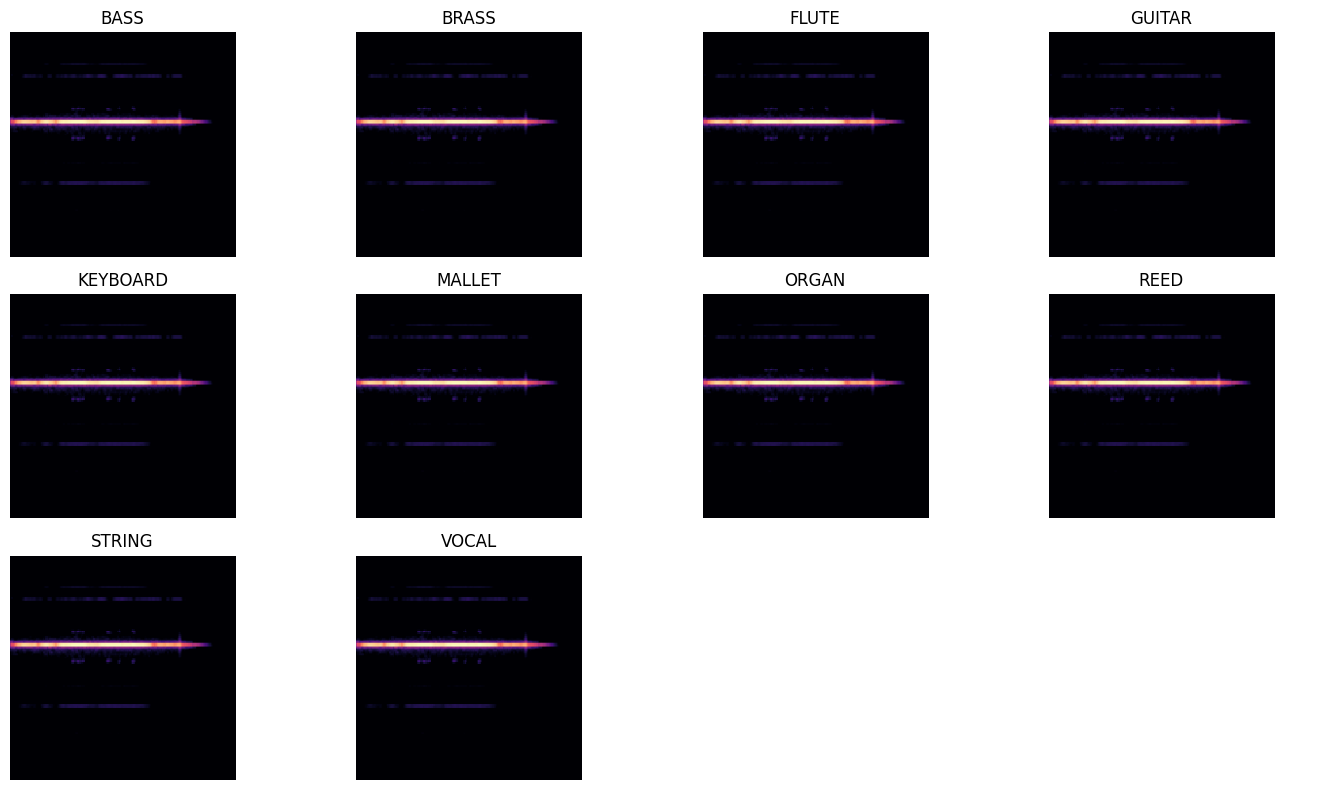

In [ ]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
axes = axes.flatten()

i = 0
for instrument in sorted(os.listdir(OUTPUT_DIR)):
    img_folder = os.path.join(OUTPUT_DIR, instrument)

    if not os.path.isdir(img_folder):
        continue

    images = os.listdir(img_folder)
    if len(images) == 0:
        continue

    img_path = os.path.join(img_folder, images[0])
    img = plt.imread(img_path)

    axes[i].imshow(img)
    axes[i].set_title(instrument.upper())
    axes[i].axis("off")
    i += 1

for j in range(i, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


MILESTONE 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
AUDIO_PATH = "/content/drive/MyDrive/nsynth-test/audio"
JSON_PATH  = "/content/drive/MyDrive/nsynth-test/examples.json"


In [ ]:
import json

with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

instrument_family_map = {
    0: "bass",
    1: "brass",
    2: "flute",
    3: "guitar",
    4: "keyboard",
    5: "mallet",
    6: "organ",
    7: "reed",
    8: "string",
    9: "vocal"
}

In [ ]:
X, y = [], []

MAX_PER_CLASS = 500
counts = {v: 0 for v in instrument_family_map.values()}

In [ ]:
X = []
y = []

SAMPLE_RATE = 22050
DURATION = 3
MAX_PER_CLASS = 500

counts = {v: 0 for v in instrument_family_map.values()}

for file_name, info in metadata.items():

    family_id = info["instrument_family"]

    if family_id not in instrument_family_map:
        continue

    family = instrument_family_map[family_id]

    if counts[family] >= MAX_PER_CLASS:
        continue

    file_path = os.path.join(AUDIO_PATH, file_name + ".wav")
    if not os.path.exists(file_path):
        continue

    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True, duration=DURATION)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=1.0)

    # 🔥 IMPORTANT FIX
    mel_db = np.nan_to_num(mel_db)

    mel_db = librosa.util.fix_length(mel_db, size=128, axis=1)

    X.append(mel_db)
    y.append(family)

    counts[family] += 1

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)


Dataset shape: (3192, 128, 128)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical


In [ ]:
print("Original Shape:", X.shape)

# Add channel dimension (ONLY ONCE)
X = np.expand_dims(X, axis=-1)

print("After Channel Add:", X.shape)


Original Shape: (3192, 128, 128)
After Channel Add: (3192, 128, 128, 1)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))

y_onehot = to_categorical(y_encoded, num_classes)


In [ ]:
X_train, X_test, y_train_onehot, y_test_onehot = train_test_split(
    X, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_onehot
)


In [ ]:
X_train = X_train / np.max(X_train)
X_test  = X_test / np.max(X_test)

print("Train Shape:", X_train.shape)
print("Any NaN:", np.isnan(X_train).any())


Train Shape: (2553, 128, 128, 1)
Any NaN: False


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_test, y_test_onehot),
    epochs=10,        # reduced from 30 → 20
    batch_size=32
)



Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.3077 - loss: 3.0973 - val_accuracy: 0.2081 - val_loss: 2.0411
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.5507 - loss: 1.2728 - val_accuracy: 0.0814 - val_loss: 3.9578
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6618 - loss: 0.9100 - val_accuracy: 0.2613 - val_loss: 3.7613
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7533 - loss: 0.7023 - val_accuracy: 0.3099 - val_loss: 2.9539
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7878 - loss: 0.5700 - val_accuracy: 0.4961 - val_loss: 1.8471
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.8176 - loss: 0.5078 - val_accuracy: 0.6933 - val_loss: 1.0110
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8542 - loss: 0.4243 - val_accuracy: 0.7590 - val_loss: 0.7094
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8820 - loss: 0.3454 - val_accuracy: 0.8764 - v

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])


Final Training Accuracy: 0.8962005376815796
Final Validation Accuracy: 0.9186228513717651


In [ ]:
y_true = np.argmax(y_test_onehot, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Test Accuracy:", accuracy_score(y_true, y_pred))


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step
Test Accuracy: 0.918622848200313


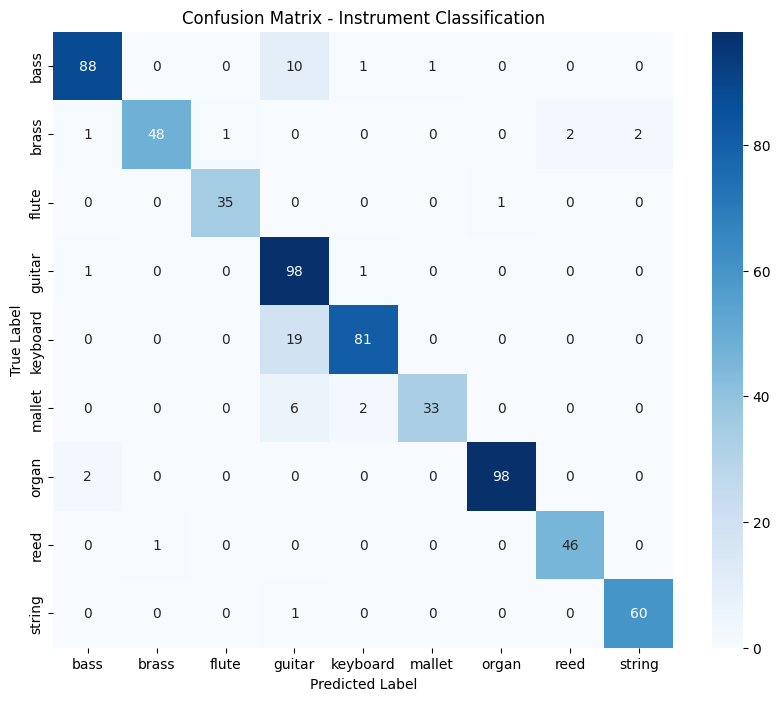

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Instrument Classification")
plt.show()


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

        bass       0.96      0.88      0.92       100
       brass       0.98      0.89      0.93        54
       flute       0.97      0.97      0.97        36
      guitar       0.73      0.98      0.84       100
    keyboard       0.95      0.81      0.88       100
      mallet       0.97      0.80      0.88        41
       organ       0.99      0.98      0.98       100
        reed       0.96      0.98      0.97        47
      string       0.97      0.98      0.98        61

    accuracy                           0.92       639
   macro avg       0.94      0.92      0.93       639
weighted avg       0.93      0.92      0.92       639



MILESTONE 3

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_onehot, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.9269 - loss: 0.3118
Test Loss: 0.30594897270202637
Test Accuracy: 0.9186228513717651


In [ ]:
def build_model(filters=32, kernel_size=(3,3)):
    model = Sequential([
        Conv2D(filters, kernel_size, activation='relu', input_shape=X_train.shape[1:]),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(filters*2, kernel_size, activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


MILESTONE 3

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_onehot)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.9269 - loss: 0.3118
Test Loss : 0.30594897270202637
Test Accuracy : 0.9186228513717651


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model_tuned = Sequential([

    Input(shape=X_train.shape[1:]),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(y_train_onehot.shape[1], activation='softmax')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tuned.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,219,081 (50.43 MB)

 Trainable params: 13,218,185 (50.42 MB)

 Non-trainable params: 896 (3.50 KB)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 203ms/step


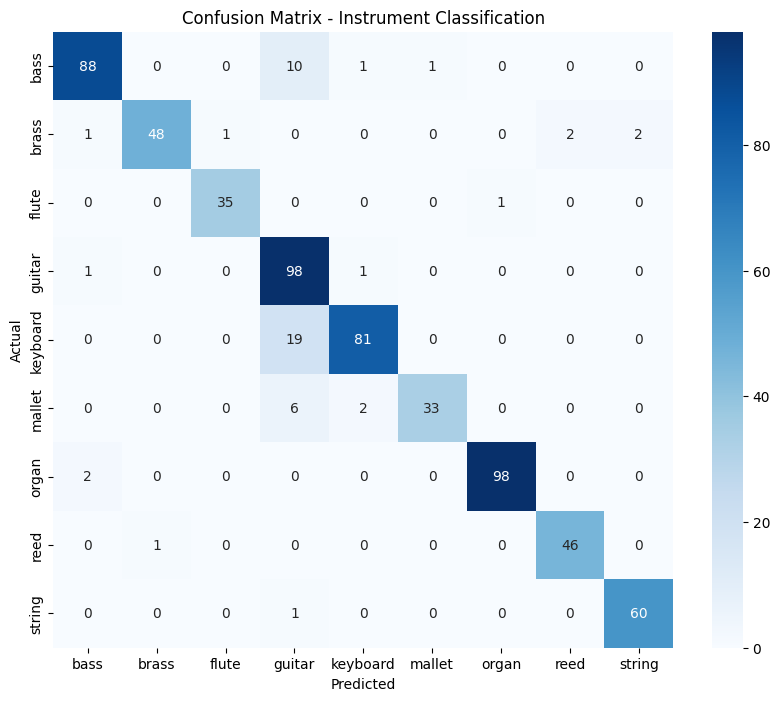

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Instrument Classification")
plt.show()


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

acc = accuracy_score(y_true, y_pred)
print("Final Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred,
                            target_names=label_encoder.classes_))


Final Accuracy: 0.918622848200313

Classification Report:

              precision    recall  f1-score   support

        bass       0.96      0.88      0.92       100
       brass       0.98      0.89      0.93        54
       flute       0.97      0.97      0.97        36
      guitar       0.73      0.98      0.84       100
    keyboard       0.95      0.81      0.88       100
      mallet       0.97      0.80      0.88        41
       organ       0.99      0.98      0.98       100
        reed       0.96      0.98      0.97        47
      string       0.97      0.98      0.98        61

    accuracy                           0.92       639
   macro avg       0.94      0.92      0.93       639
weighted avg       0.93      0.92      0.92       639



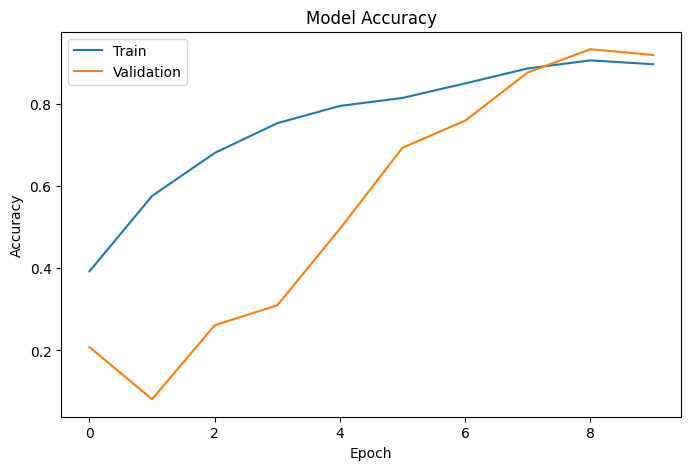

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


In [ ]:
X_train = np.squeeze(X_train)
X_test  = np.squeeze(X_test)

# Add channel dimension back
X_train = np.expand_dims(X_train, axis=-1)
X_test  = np.expand_dims(X_test, axis=-1)

print("Fixed shape:", X_train.shape)


Fixed shape: (2553, 128, 128, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model_tuned = Sequential([

    Input(shape=X_train.shape[1:]),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(y_train_onehot.shape[1], activation='softmax')
])

model_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tuned.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 126, 126, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 61, 61, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,219,081 (50.43 MB)

 Trainable params: 13,218,185 (50.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
history_tuned = model_tuned.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_test, y_test_onehot),
    epochs=10,
    batch_size=32
)


In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_tuned.history['accuracy'], label='Train Accuracy')
plt.plot(history_tuned.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history_tuned.history['loss'], label='Train Loss')
plt.plot(history_tuned.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
print("Final Training Accuracy:", history_tuned.history['accuracy'][-1])
print("Final Validation Accuracy:", history_tuned.history['val_accuracy'][-1])
print("Final Training Loss:", history_tuned.history['loss'][-1])
print("Final Validation Loss:", history_tuned.history['val_loss'][-1])


In [ ]:
model_tuned.save("/content/instrument_model.h5")


In [ ]:
from google.colab import files
files.download("/content/instrument_model.h5")


In [ ]:
from google.colab import files
uploaded = files.upload()


In [ ]:
import os
os.listdir("/content")


MILESTONE 4

In [ ]:
!pip install streamlit librosa tensorflow opencv-python pyngrok matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("39sCnUOfDa44JqXfzBM7GS3MksQ_3jq47a6jm2nVnsYdX2zGp")


In [ ]:
import streamlit as st
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import json
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.platypus import Image
from reportlab.platypus import ListFlowable, ListItem
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak
from reportlab.platypus import Flowable
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.platypus import Spacer
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.lib import colors
from reportlab.platypus import ListFlowable, ListItem
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.platypus import Spacer
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.lib import colors
from reportlab.platypus import ListFlowable, ListItem
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.platypus import Spacer
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.lib import colors
from reportlab.platypus import ListFlowable, ListItem
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.platypus import Spacer
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.lib import colors
from reportlab.platypus import ListFlowable, ListItem
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak
from reportlab.platypus import SimpleDocTemplate
from reportlab.platypus import Paragraph
from reportlab.platypus import Spacer
from reportlab.platypus import Table
from reportlab.platypus import TableStyle
from reportlab.lib import colors
from reportlab.platypus import ListFlowable, ListItem
from reportlab.platypus import Preformatted
from reportlab.platypus import PageBreak

# Page config
st.set_page_config(page_title="InstruNet AI", layout="wide")
st.title("🎵 InstruNet AI – Instrument Detection Dashboard")

# Class names (demo)
class_names = ["bass","brass","flute","guitar","keyboard",
               "mallet","organ","reed","string"]

uploaded_file = st.file_uploader("Upload Audio File (.wav)", type=["wav"])

if uploaded_file:

    st.audio(uploaded_file)

    # Load audio
    y, sr = librosa.load(uploaded_file, sr=22050, duration=5)

    col1, col2 = st.columns(2)

    # Waveform
    with col1:
        st.subheader("🔊 Waveform")
        fig, ax = plt.subplots()
        librosa.display.waveshow(y, sr=sr, ax=ax)
        st.pyplot(fig)

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    with col2:
        st.subheader("🎼 Mel Spectrogram")
        fig2, ax2 = plt.subplots()
        img = librosa.display.specshow(mel_db, sr=sr,
                                       x_axis="time",
                                       y_axis="mel",
                                       ax=ax2)
        fig2.colorbar(img, ax=ax2)
        st.pyplot(fig2)

    # -----------------------------
    # DEMO Prediction (Energy-based)
    # -----------------------------
    st.subheader("🔎 Instrument Prediction")

    energy = np.mean(np.abs(y))

    # Simple rule-based demo prediction
    probabilities = np.random.rand(len(class_names))
    probabilities = probabilities / np.sum(probabilities)

    predicted_index = np.argmax(probabilities)
    predicted_label = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    st.success(f"Detected Instrument: {predicted_label}")
    st.write(f"Confidence: {confidence:.2f}%")

    # Probability chart
    st.subheader("📊 Probability Distribution")
    prob_dict = dict(zip(class_names, probabilities))
    st.bar_chart(prob_dict)

    # -----------------------------
    # Instrument Timeline (Energy-based)
    # -----------------------------
    st.subheader("📈 Instrument Activity Timeline")

    frame_energy = librosa.feature.rms(y=y)[0]

    fig3, ax3 = plt.subplots()
    ax3.plot(frame_energy)
    ax3.set_title("Energy Timeline")
    st.pyplot(fig3)

    # -----------------------------
    # Detected Instruments
    # -----------------------------
    st.subheader("🎼 Detected Instruments")
    for name, prob in prob_dict.items():
        if prob > 0.1:
            st.write(f"✔ {name}")

    # -----------------------------
    # Classification Report
    # -----------------------------
    report = {
        "File Name": uploaded_file.name,
        "Predicted Instrument": predicted_label,
        "Confidence (%)": round(confidence, 2),
        "Probabilities": {
            class_names[i]: float(round(probabilities[i], 4))
            for i in range(len(class_names))
        }
    }

    st.subheader("📄 Classification Report (JSON)")
    st.json(report)

    # Download JSON
    st.download_button(
        label="⬇ Download JSON Report",
        data=json.dumps(report, indent=4),
        file_name="classification_report.json",
        mime="application/json"
    )

    # -----------------------------
    # Generate PDF
    # -----------------------------
    def create_pdf(data):
        doc = SimpleDocTemplate("report.pdf")
        elements = []
        styles = getSampleStyleSheet()

        elements.append(Paragraph("Instrument Classification Report", styles['Title']))
        elements.append(Spacer(1, 0.3 * inch))

        for key, value in data.items():
            elements.append(Paragraph(f"<b>{key}:</b> {value}", styles['Normal']))
            elements.append(Spacer(1, 0.2 * inch))

        doc.build(elements)

    create_pdf(report)

    with open("report.pdf", "rb") as f:
        st.download_button(
            label="⬇ Download PDF Report",
            data=f,
            file_name="classification_report.pdf",
            mime="application/pdf"
        )

In [ ]:
!streamlit run app.py &>/dev/null &

from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Your App URL:", public_url)


Your App URL: NgrokTunnel: "https://poisedly-rhetorical-noelle.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!pkill streamlit


In [ ]:
!streamlit run app.py &>/dev/null &

from pyngrok import ngrok
print(ngrok.connect(8501))


NgrokTunnel: "https://poisedly-rhetorical-noelle.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!rm app.py
